# Ajustes de parâmetros LLM para controle da geração de textos

André Luiz Peron Martins Lanna (andrelanna@unb.br)  
CEDIS - Centro de Estudos, Desenvolvimento e Inovação em Software  
FCTE - Faculdade de Ciência e Tecnologia em Engenharias  
UnB - Universidade de Brasilia  

---

# Large Language Models (LLMs)

Large Language Models (LLMs) são avançados sistemas de inteligência artificial criados para entender e gerar texto de maneira similar à escrita humana. 

Basicamente, um LLM pode prever, **com base em distribuições de probabilidade**, qual será a próxima palavra em uma frase, ajudar a escrever textos completos e até responder perguntas complexas.

Esses modelos são redes neurais com várias aplicações práticas, treinados com vastas quantidades de dados textuais, utilizam um número significativamente grande de parâmetros, muitas vezes na casa dos bilhões ou até trilhões. 



## Transformers
Transformer é uma arquitetura de rede neural utilizada em vários domínios, incluindo imagens e sons. 
No caso de textos, os transformadores funcionam buscando prever qual a próxima palavra mais provável dentro de um prompt. Proposta por pesquisadores da Google e da Universidade de Toronto, publicada em 2017 no artigo [Attention Is All You Need](https://dl.acm.org/doi/pdf/10.5555/3295222.3295349). **A inovação está no mecanismo de auto-atenção, que é capaz de capturar dependências de longa alcance entre termos**. 

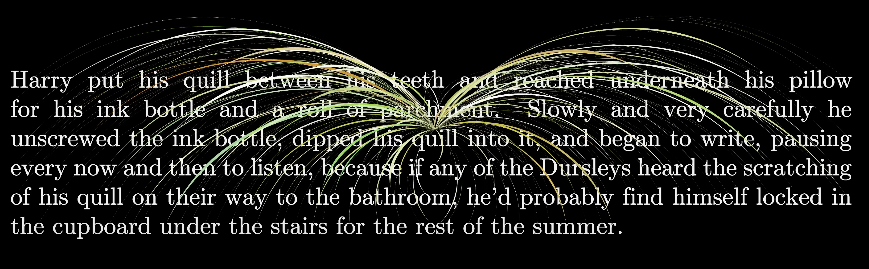   
Fonte: [Transformers (how LLMs work) explained visually (Youtube)](https://www.youtube.com/watch?v=wjZofJX0v4M)

LLMs utilizam arquiteturas avançadas baseadas em transformadores (_Transformers_) para aprender padrões complexos em grandes volumes de texto. Dividido em três componentes: 
1. **Incorporação**: divide a entrada em unidades menores, chamadas _tokens_, podendo ser palavras inteiras ou sub-palavras. As tokens são convertidas em valores numéricos que representam sua semântica. 
2. **Bloco transformador**: processa e transforma os dados de entrada. 
3. **Probabilidades de saída**: o softmax transformam as incorporações processadas em **probabilidades**, de modo que o modelo possa fazer previsões sobre o token que virá em seguida.

Demonstração em uma ferramenta muito útil, chamada [Transformer Explainer](https://poloclub.github.io/transformer-explainer/), apenas para frases em inglês e limitada a 12 palavras. 
Exemplos: 
- The pythagoreans ...
- Socrates was ...
- Estoicism is ...

Note que, a cada iteração, é produzida uma lista de tokens com uma distribuição de probabilidade. O valor associado a cada token indica a probabilidade dela ser selecionada pela função de amostragem. 

Em seguida, serão apresentados os parâmetros que nos permite influenciar a distribuição de probabilidades a cada iteração, de modo a adaptar um modelo LLM para algum uso específico. 


---

## Temperatura (= Controle da criatividade)
É um dos controles mais importantes de um LLM. 
Ele define a "criatividade" de uma LLM. 
O valor que ela assume vai determinar as probabilidades das tokens na saída de cada iteração. Valores mais baixos fazem com a token de maior probabilidade domine a distribuição probabilística, valores mais altos fazem com que a distribuição se torne mais uniforme. 

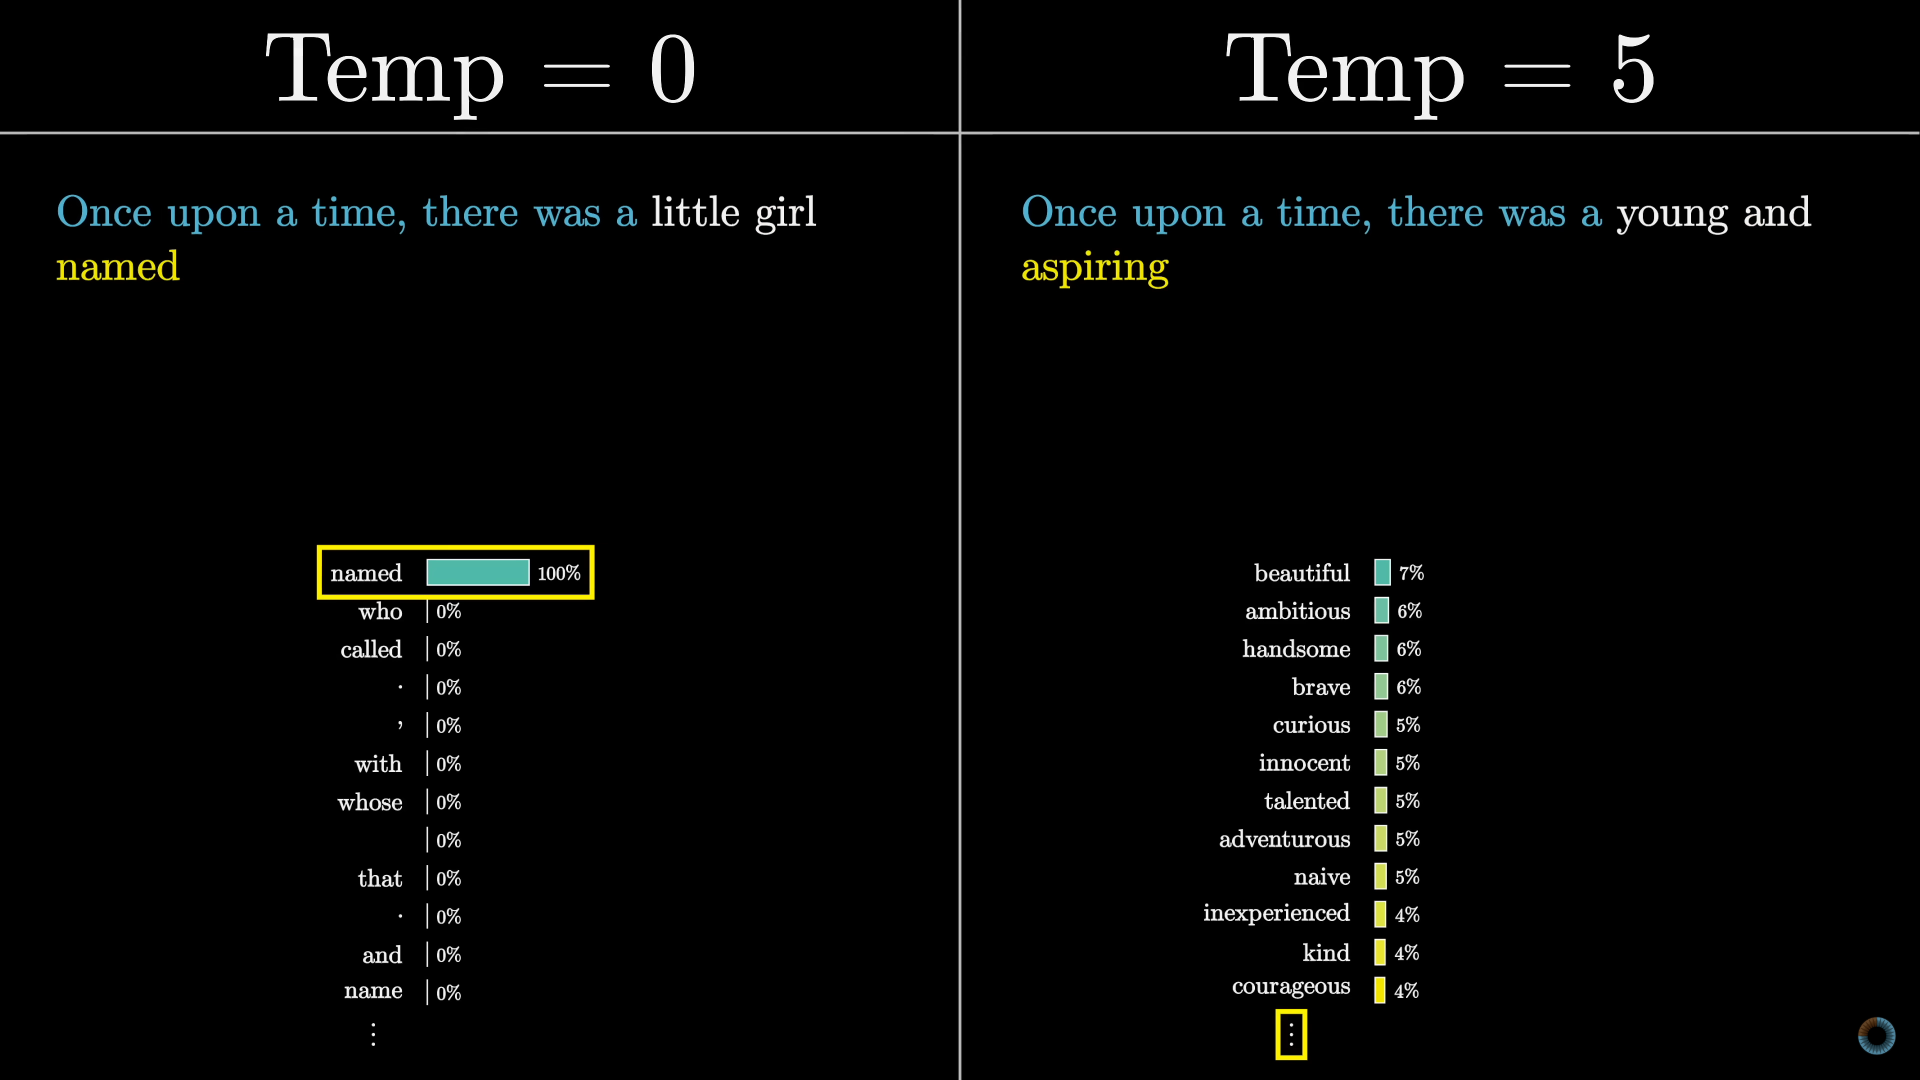
Fonte: [Transformers (how LLMs work) explained visually](https://youtu.be/wjZofJX0v4M?si=e-embCZ9rWxLkHjD&t=1380)

Vide exemplo em: [Transformers (how LLMs work) explained visually](https://youtu.be/wjZofJX0v4M?si=e-embCZ9rWxLkHjD&t=1380)

- *$\approx 0.2$*: o modelo não tem criatividade, suas respostas são formadas por tokens altamente prováveis, perfeita para escritas factuais ou codificação;
- *$\approx 0.8$*: o modelo começa a ganhar criatividade, começa a tomar riscos nas escolhas de palavras. Ideal para _brainstorming_ ou escrita criativa;
- *$1.5+$*: experimental, respostas caóticas.

---

# Top-P (= amostragem de núcleo)
Esse parâmetro vai escolher, por amostragem, as tokens mais prováveis de somarem um limiar $p$.  
Intervalo: $[0, 1]$.  
Enquanto a temperatura define os valores de probabilidade de cada token, a amostragem Top-P vai calcular a probabilidade acumulada das tokens e vai selecionar aquelas que estão dentro desse valor obtido. 

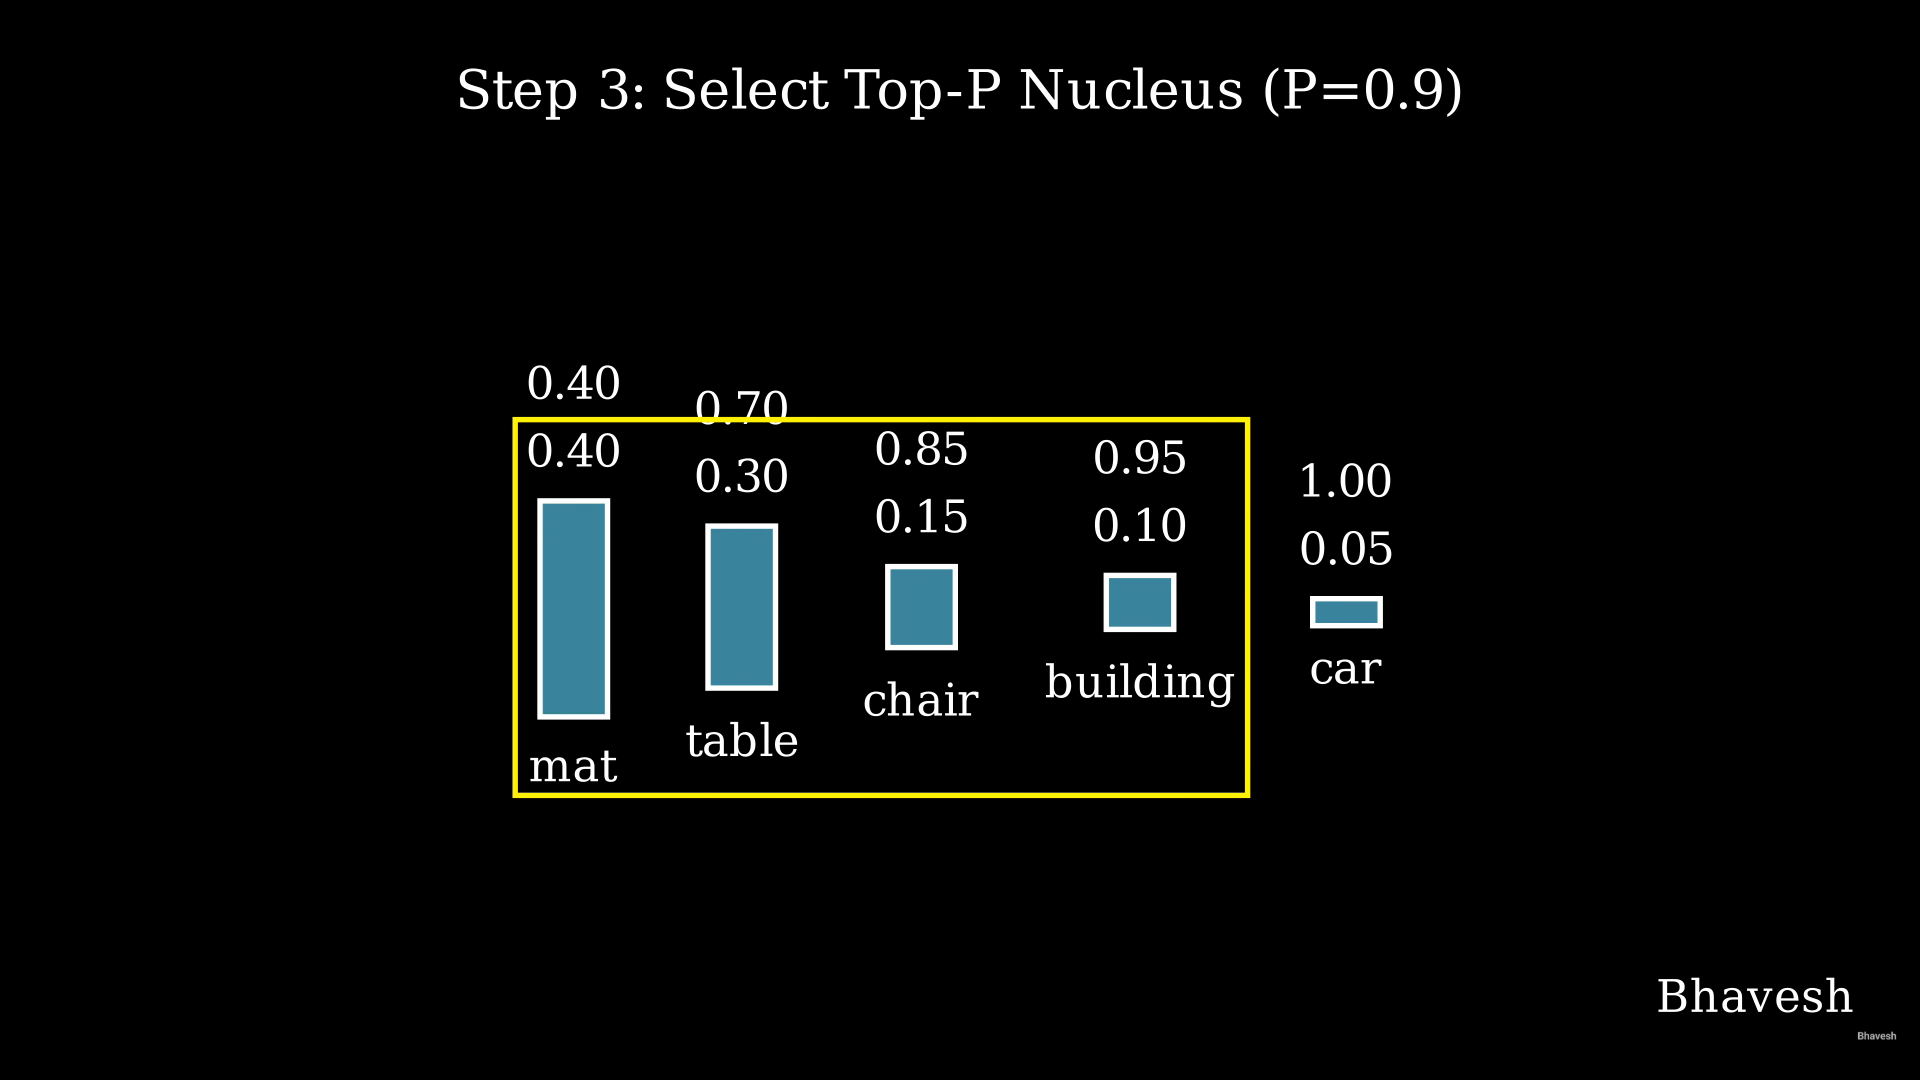
Fonte: [LLM Basics: Top-p vs. Top-K Sampling Explained for Beginners](https://www.youtube.com/watch?v=_3DWwb96exY)

Valores mais baixos para $p$ deixarão o texto mais "focado", utilizando apenas as tokens mais prováveis. Valores mais altos para $p$ deixarão o testo mais criativo ao passo que a coerência ainda será mantida. 

Obs.: o ajuste desse parâmetro oferece um equilíbrio entre criatividade e coerência. 

Exemplo no [Transformer Explainer](https://poloclub.github.io/transformer-explainer/), com $p \leq 0.7$.
- Estoicism was...

---

# Top-k (= _hard limit_)
Com esse parâmetro define-se um limite das tokens que serão escolhidas por amostragem durante a criação das sentenças. Colocadas em ordem decrescente de probabilidade, as _k_ primeiras tokens estarão disponíveis para seleção pela função de amostragem. 

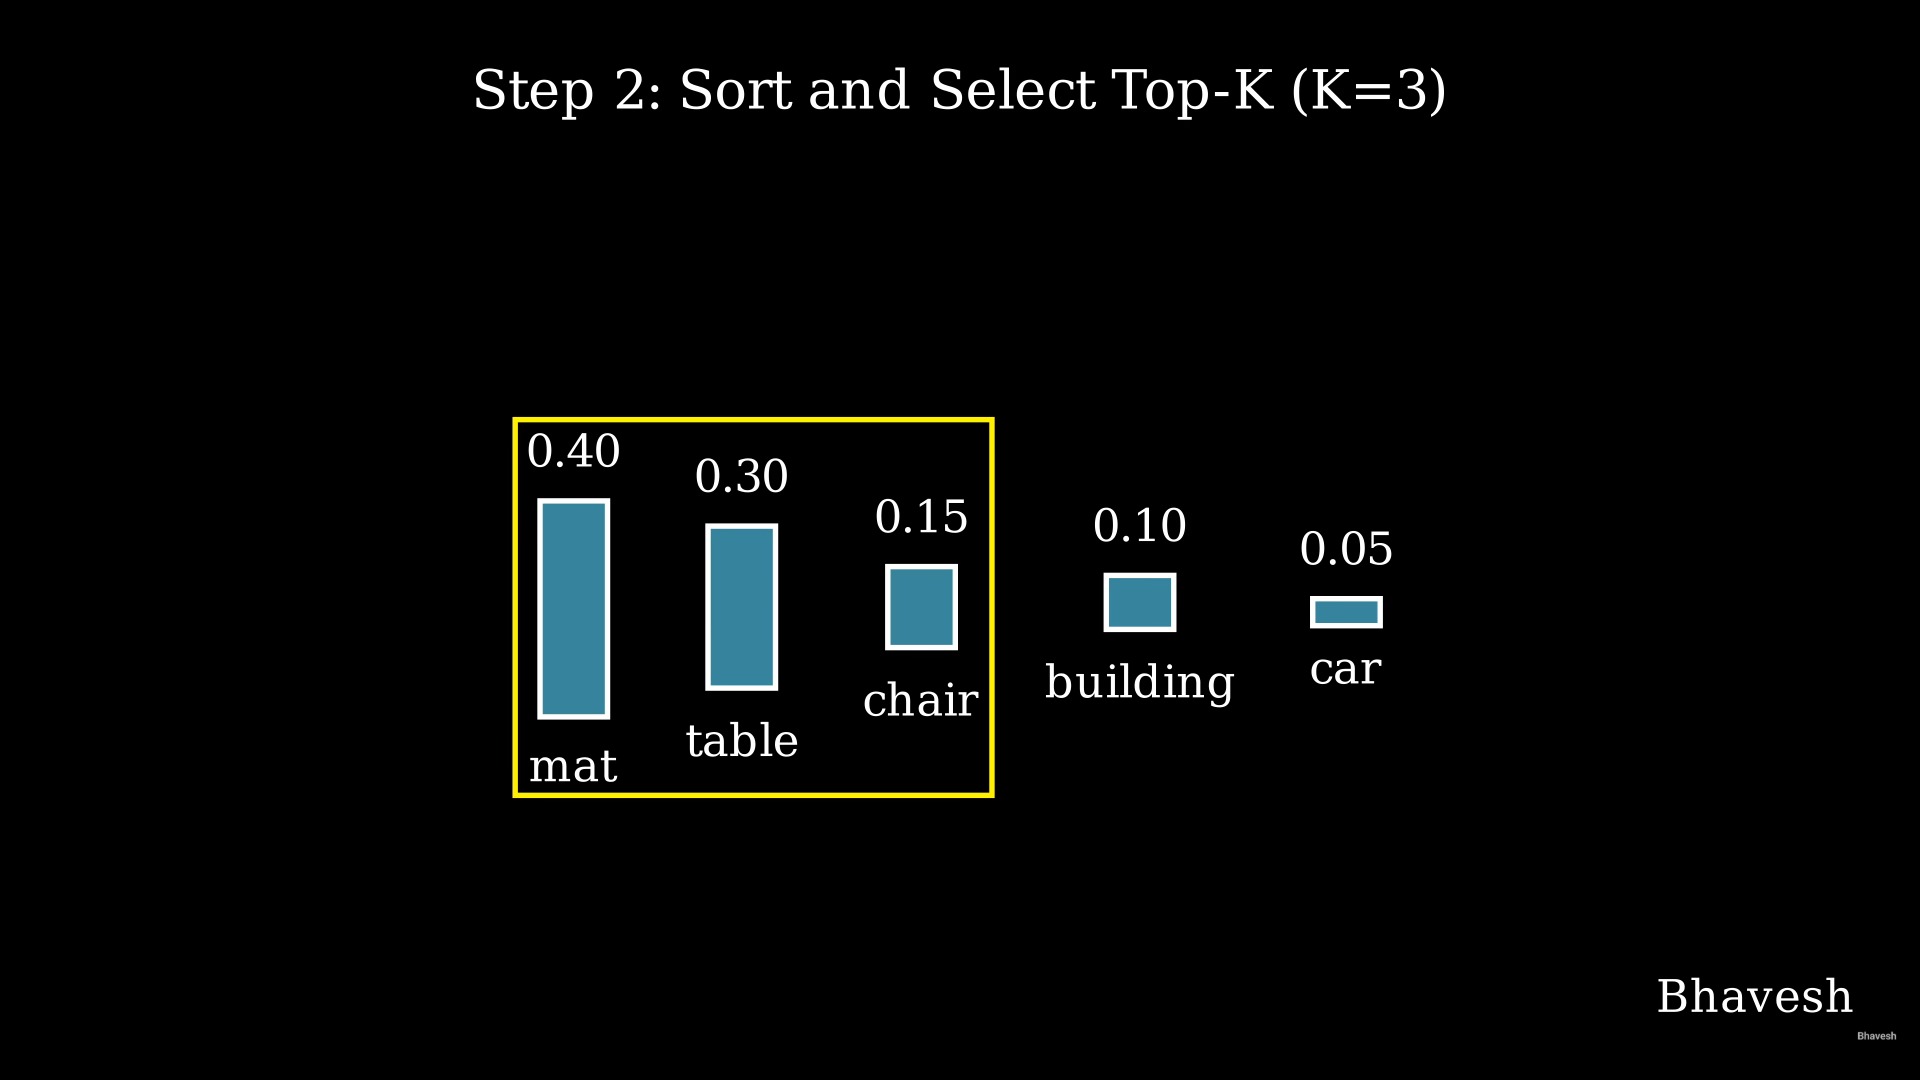
Fonte: [LLM Basics: Top-p vs. Top-K Sampling Explained for Beginners](https://www.youtube.com/watch?v=_3DWwb96exY)

Exemplo no [Transformer Explainer](https://poloclub.github.io/transformer-explainer/), com $2 \leq k \leq 5$.
- Estoicism was...

Observação: valores baixos de $k$ deixarão o texto mais "focado", contudo com mais repetições. Valores altos de $k$ deixarão o texto com mais variações mas, também, com tokens menos relevantes. 

---

# Conclusão

- LLMs são baseadas na arquitetura chamada Transformers que cria _tokens_ a partir de uma entrada, calcula a proximidade dessas tokens com as demais, e define probabilidade das tokens ao final de cada iteração.
- O parâmetro **Temperatura** vai definir os valores de probabilidade de cada token ao final de cada iteração.
    - A "criatividade" do texto depende desse parâmetro. Valores baixos $\rightarrow$ menor criatividade; valores altos $\rightarrow$ maior criatividade.
- O parâmetro **Top-P** vai definir o tamanho da janela de tokens a cada iteração por um limiar $p$ definido pelo usuário.
    - As tokens cujas probabilidades somadas estiverem dentro do limiar $p$, serão candidatas à seleção por amostragem.
    - Janela de tamanho variável. 
    - Valores baixos de $p \rightarrow$ texto mais focado, valores altos de $p \rightarrow$ texto mais criativo.
- O parâmetro **Top-K** vai definir uma janela de tamanho fixo $k$, com tokens em ordem decrescente de probabilidade.
    - Valores baixos de $k \rightarrow$ escolha menos determinística do texto produzido.
    - Valores altos de $k \rightarrow$ escolha mais determinística do texto produzido.
- O uso conjugado dos parâmetros, especialmente **Top-P** e **Top-K**, pode ser feito para controlar as características dos textos produzidos por uma LLM.

---

# Referências: 
- Azimov Academy. _LLM: o que é e como funciona um grande modelo de linguagem_. URL: [https://hub.asimov.academy/blog/large-language-models-llm-o-que-e/#o-que-e-llm](https://hub.asimov.academy/blog/large-language-models-llm-o-que-e/#o-que-e-llm)
- Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, and Illia Polosukhin. 2017. [Attention is all you need](https://dl.acm.org/doi/10.5555/3295222.3295349). In Proceedings of the 31st International Conference on Neural Information Processing Systems (NIPS'17). Curran Associates Inc., Red Hook, NY, USA, 6000–6010.
- Transformer Explainer. _O que é um Transformer?_ [https://poloclub.github.io/transformer-explainer/](https://poloclub.github.io/transformer-explainer/)
- How Large Language Models Work. URL: [https://www.youtube.com/watch?v=5sLYAQS9sWQ]/(https://www.youtube.com/watch?v=5sLYAQS9sWQ)
- Transformers (how LLMs work) explained visually. URL: [https://www.youtube.com/watch?v=wjZofJX0v4M](https://www.youtube.com/watch?v=wjZofJX0v4M)
- Bhaskar, Yash. The Complete Guide to LLM Parameters: How to Control AI Text Generation. URL: [https://medium.com/@yash9439/the-complete-guide-to-llm-parameters-how-to-control-ai-text-generation-fdbb33dbbdfe](https://medium.com/@yash9439/the-complete-guide-to-llm-parameters-how-to-control-ai-text-generation-fdbb33dbbdfe)
